<a href="https://colab.research.google.com/github/FelimProject/gender_classifier_using_resnet/blob/main/computer_vision_gender_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h1>1. Data Loading for load the</h1>**



*   Make datatests folder place the date
*   Download dataset from source



In [ ]:
import os


PATH = '/content/dataset'
DATA_PATH = '/content/dataset/Images'

if not os.path.exists(PATH):
  os.mkdir(PATH)


Check the GPU is available or not because we will use GPU for training

In [ ]:
!nvidia-smi

Mon Mar  9 00:50:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Install library gdown lo easily download file from outside


In [ ]:
!pip install gdown

Import the dataset to the directory

In [ ]:
import gdown, zipfile, os

if not os.path.exists(f'{PATH}/list.txt'):
    os.makedirs(PATH, exist_ok=True)
    url = 'https://drive.google.com/uc?id=16K1Luqqa496n5Oe1XIDWd3llgMMp93vH'
    gdown.download(url, f"{PATH}/list.txt", quiet=False)

if not os.path.exists(DATA_PATH):
    os.makedirs(DATA_PATH, exist_ok=True)
    url = "https://drive.google.com/uc?id=1MabG8IDYbKVyPDKwl0GnPvQ4csywDYy0"
    gdown.download(url, f"{PATH}/Images.zip", quiet=False)

    with zipfile.ZipFile(f"{PATH}/Images.zip", 'r') as z:
        z.extractall(PATH)

    print("Done!")

Downloading...
From: https://drive.google.com/uc?id=16K1Luqqa496n5Oe1XIDWd3llgMMp93vH
To: /content/dataset/list.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 58.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1MabG8IDYbKVyPDKwl0GnPvQ4csywDYy0
From (redirected): https://drive.google.com/uc?id=1MabG8IDYbKVyPDKwl0GnPvQ4csywDYy0&confirm=t&uuid=7c2abf0a-9d43-4726-b40f-af59039d0f81
To: /content/dataset/Images.zip
100%|██████████| 35.8M/35.8M [00:00<00:00, 55.2MB/s]


Done!


**<h1>2. Data Exploratory to cleaning data</h1>**



*  Load data into dataframe

*  Change the dataframe negative labels from -1 to 0
* Check null values
* Clear the dataframe to make sure load the image that only exists in folder
* Verify the file is not corrupted file
* Check the size from dataset make sure all is same size



In [ ]:
import pandas as pd
import re

with open(f"{PATH}/list.txt", "r") as f:
    lines = f.readlines()

attr_names = lines[1].strip().split()

data = []
for line in lines[2:]:
    parts = line.strip().split()
    if not parts:
        continue
    filename = parts[0]
    attrs = [int(x) for x in parts[1:] if x in ('1', '-1')]
    data.append([filename] + attrs)

columns = ["filename"] + attr_names

n_attrs = len(attr_names)
data = [row for row in data if len(row) == n_attrs + 1]

df = pd.DataFrame(data, columns=columns)
print(df.head(10))

     filename  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   
5  000006.jpg                -1                1           1               -1   
6  000007.jpg                 1               -1           1                1   
7  000008.jpg                 1                1          -1                1   
8  000009.jpg                -1                1           1               -1   
9  000010.jpg                -1               -1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -

Change the -1 values to 0 to make sure the label is acceptable for model

In [ ]:
df = df[['filename', 'Male']]
df.loc[df['Male'] == -1, 'Male'] = 0
df

,filename,Male
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,1
3,000004.jpg,0
4,000005.jpg,0
...,...,...
202594,202595.jpg,0
202595,202596.jpg,1
202596,202597.jpg,1
202597,202598.jpg,0


Check null values make sure there is no value for the data if the null values is exists we need to clean it up first

In [ ]:
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nUnique values in 'Male': {df['Male'].unique()}")
print(f"\nValue counts:\n{df['Male'].value_counts()}")

ext = df['filename'].str.split('.').str[-1].str.lower()

print(f"\nExtension Value counts:\n{ext.value_counts()}")

Shape: (202599, 2)

Dtypes:
filename    object
Male         int64
dtype: object

Null values:
filename    0
Male        0
dtype: int64

Unique values in 'Male': [0 1]

Value counts:
Male
0    118165
1     84434
Name: count, dtype: int64

Extension Value counts:
filename
jpg    202599
Name: count, dtype: int64


Print the count of images

In [ ]:
import os

image_list = [f for f in os.listdir(DATA_PATH) if f.lower().endswith(('.jpg'))]

print(f"Number of images : {len(image_list)}")

Number of images : 5017


Make sure the dataframe only include the files that is exists in image folder

In [ ]:
df = df[df['filename'].isin(image_list)]
print(f"Shape after filter: {df.shape}")

df.head(10)

Shape after filter: (5000, 2)


,filename,Male
50,000051.jpg,1
51,000052.jpg,1
64,000065.jpg,1
165,000166.jpg,1
197,000198.jpg,0
200,000201.jpg,0
239,000240.jpg,0
281,000282.jpg,1
351,000352.jpg,1
408,000409.jpg,1


Check corrupted files to make sure there is not corrupted files in folders

In [ ]:
from PIL import Image
def is_valid(filename):
    path = os.path.join(DATA_PATH, filename)
    try:
        with Image.open(path) as img :
          img.verify()
          return True
    except:
        return False

print(f"Corrupt files: {(~ df['filename'].apply(is_valid)).sum()}")

Corrupt files: 0


Check te sizes of files to make sure there is not different image sizes in folders

In [ ]:
import os
from PIL import Image
from collections import Counter

def check_image_size(df, DATA_PATH):
  sizes = []

  for filename in df['filename']:
    path = os.path.join(DATA_PATH, filename)

    with Image.open(path) as img:
      width, height = img.size
      sizes.append((width, height))

  size_count = Counter(sizes)

  print("Different Image size :", len(size_count))
  print("\nDetail size:")

  for size, count in size_count.items():
    print(f"Size {size} : {count} gambar")

  return size_count

In [ ]:
check_image_size(df, DATA_PATH)

Different Image size : 1

Detail size:
Size (178, 218) : 5000 gambar


Counter({(178, 218): 5000})

plot first 10 image to visualize our image and make sure it is clean

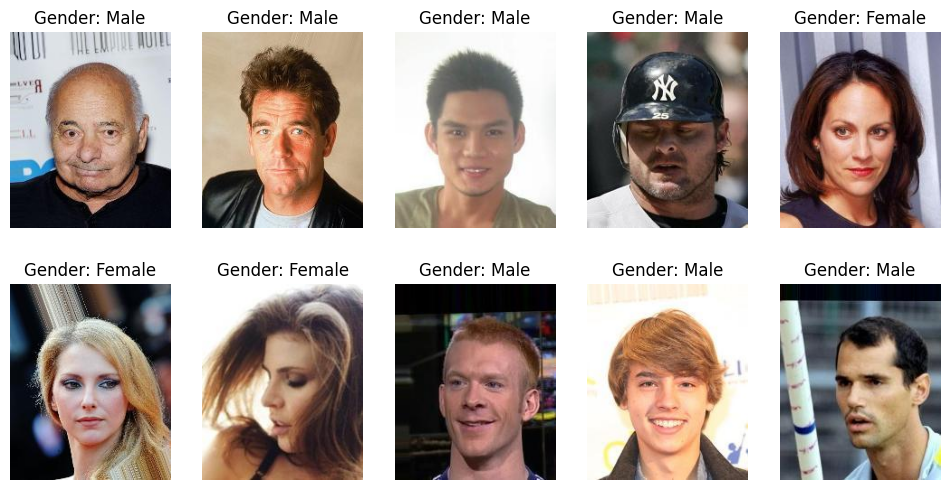

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i , ax in enumerate(axes.flatten()):
    row = df.iloc[i]
    dir = f"{DATA_PATH}/{row['filename']}"
    image = Image.open(dir)
    ax.imshow(image)
    ax.set_title(f"Gender: {'Male' if row['Male'] == 1 else 'Female'}")
    ax.axis('off')


**<h1>3. Data Preprocessing before training</h1>**



*  Split the dataset using stratify sampling in training set and random sampling in validate and test set

* Construct a PyTorch Dataset from the dataframe
* Set the device into cuda
* Set manual seed
* Define matrices

Split the dataset using the stratify sampling in training set and use random sampling in validate and test set , stratify to training set to make sure the training set is balance.

In [ ]:
from sklearn.model_selection import train_test_split

male_df = df[df['Male'] == 1]
female_df = df[df['Male'] == 0]

male_train = male_df.sample(1750, random_state=42)
female_train = female_df.sample(1750, random_state=42)

df_train = pd.concat([male_train, female_train])

df_rest = df.drop(df_train.index)

df_val , df_test = train_test_split(df_rest, test_size=500, random_state=42)

print(f"Train samples: {len(df_train)}")
print(f"Validation samples: {len(df_val)}")
print(f"Test samples: {len(df_test)}")

Train samples: 3500
Validation samples: 1000
Test samples: 500


Check the data count for each samples to make sure the training samples is balance

In [ ]:
def check_data_count(df):
    num_male = (df['Male'] == 1).sum()
    print(f"Male count: {num_male}")
    print(f"Percent count Male: {num_male / len(df) * 100:.2f} %")

    num_female = (df['Male'] == 0).sum()
    print(f"Female count: {num_female}")
    print(f"Percent count Female: {num_female / len(df) * 100:.2f} %")

In [ ]:
for df in (df_train , df_val, df_test):
  check_data_count(df)

  print('\n')

Male count: 1750
Percent count Male: 50.00 %
Female count: 1750
Percent count Female: 50.00 %


Male count: 203
Percent count Male: 20.30 %
Female count: 797
Percent count Female: 79.70 %


Male count: 94
Percent count Male: 18.80 %
Female count: 406
Percent count Female: 81.20 %




**<h1>4. Data Modelling</h1>**



* Define the matrices

* Define the models
* Hyperparameter tuning
* Data training

Install torchmetrics to use the metrics for this classification problem

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 38.1 MB/s eta 0:00:00


Import the library that we will use to train the model and set the device as gpu, Choosse the model that will be use, for to solve this classification problem we will use this models :

* Resnet18
* Resnet50
* Resnet152


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam,AdamW
from torchmetrics.classification import BinaryAccuracy , BinaryAUROC, BinaryF1Score
from torch.utils.data import Dataset , DataLoader
from torchvision.models import resnet50 , ResNet50_Weights , resnet18 , ResNet18_Weights, resnet152, ResNet152_Weights

transformResnet50 = ResNet50_Weights.DEFAULT.transforms()
transformResnet18 = ResNet18_Weights.DEFAULT.transforms()
transformResnet152 = ResNet152_Weights.DEFAULT.transforms()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

check device make sure torch is running in cuda

In [ ]:
device.type

'cuda'

In [ ]:
transformResnet50 , transformResnet18, transformResnet152

(ImageClassification(
     crop_size=[224]
     resize_size=[232]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BILINEAR
 ),
 ImageClassification(
     crop_size=[224]
     resize_size=[256]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BILINEAR
 ),
 ImageClassification(
     crop_size=[224]
     resize_size=[232]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BILINEAR
 ))

Define the dataset to pytorch format, to make it processable for training in pytorch

In [ ]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset

class ImageDataset(Dataset):

    def __init__(self, df, img_dir, transform=None, device='cpu'):
        self.data = df
        self.img_dir = img_dir
        self.transform = transform
        self.device = device

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        label = self.data.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)

        image = image.to(self.device)
        label = torch.tensor(label, dtype=torch.long, device=self.device)

        return image, label

In [ ]:
dataset_train = ImageDataset(df_train , DATA_PATH, transform=None, device=device)
dataset_val = ImageDataset(df_val, DATA_PATH, transform=None, device=device)
dataset_test = ImageDataset(df_test, DATA_PATH, transform=None, device=device)


Load the dataset into the dataloader

In [ ]:
batch_size = 32

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=batch_size, shuffle=False,)

Set the random seed

In [ ]:
import numpy as np

def set_seed(seed=42):
    torch.manual_seed(seed)
    if device.type == 'cuda':
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(42)


Define the matrices that will be use for our classification problem :

* **Accuracy** : the number of correct predictions divided by the total number of predictions. It measures the overall performance of the model in correctly classifying both positive and negative samples.

$$
Acc = \frac{TP + TN}{TP + TN + FP + FN}
$$

* **F1 Score** : the harmonic mean of precision and recall. It provides a balance between precision and recall, especially useful when dealing with imbalanced datasets.

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

* **AUROC (Area Under the Receiver Operating Characteristic Curve)** : a metric that measures the ability of a model to distinguish between classes. A higher AUROC value indicates that the model is better at separating positive and negative classes.

$$
AUC = \int_{0}^{1} \frac{TP}{TP + FN}\, d\left(\frac{FP}{FP + TN}\right)
$$

In [ ]:
accuracy = BinaryAccuracy().to(device)
f1_score = BinaryF1Score().to(device)
binary_auc = BinaryAUROC().to(device)

criterion = nn.BCEWithLogitsLoss().to(device)

Define the training functions :

*   Define the evaluate step
*   Define the test step
*   Define the train step



Define evaluate step that will be use for validation

In [ ]:
def evaluate_step(model, val_loader,criterion ,accuracy , f1_score , binary_auc):

    accuracy.reset()
    f1_score.reset()
    binary_auc.reset()
    model.eval()

    total_loss = 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(val_loader):

            X, y = X.to(device), y.float().to(device)
            y_pred = model(X).squeeze(1)
            loss = criterion(y_pred, y)
            total_loss += loss.item()

            sigmoid = torch.sigmoid(y_pred)
            accuracy.update(sigmoid, y.int())
            f1_score.update(sigmoid, y.int())
            binary_auc.update(sigmoid, y.int())

    val_loss = total_loss / len(val_loader)
    val_acc  = accuracy.compute().item()
    va_f1 = f1_score.compute().item()
    val_auc = binary_auc.compute().item()

    return val_acc, val_loss , va_f1 , val_auc


Define test step that will be use for test

In [ ]:
from sklearn.metrics import confusion_matrix

def test_step(model, test_loader, criterion, accuracy, f1_score, binary_auc):
    model.eval()

    accuracy.reset()
    f1_score.reset()
    binary_auc.reset()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for batch, (X, y) in enumerate(test_loader):
            X, y = X.to(device), y.float().to(device)

            y_pred = model(X).squeeze(1)
            loss = criterion(y_pred, y)
            total_loss += loss.item()

            sigmoid = torch.sigmoid(y_pred)

            accuracy.update(sigmoid, y.int())
            f1_score.update(sigmoid, y.int())
            binary_auc.update(sigmoid, y.int())

            preds_label = (sigmoid >= 0.5).int()
            all_preds.append(preds_label.cpu())
            all_labels.append(y.int().cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

    val_loss = total_loss / len(test_loader)
    val_acc = accuracy.compute().item()
    val_f1 = f1_score.compute().item()
    val_auc = binary_auc.compute().item()

    return val_acc, val_loss, val_f1, val_auc, cm

Define train step that will be use for training

In [ ]:
def train_step(model, optimizer, train_loader, criterion, accuracy, f1_score , binary_auc):

    model.train()
    accuracy.reset()
    f1_score.reset()
    binary_auc.reset()
    total_loss = 0.0

    for batch, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.float().to(device)

        optimizer.zero_grad()

        y_pred = model(X).squeeze(1)
        loss = criterion(y_pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        sigmoid = torch.sigmoid(y_pred)
        accuracy.update(sigmoid, y.int())
        f1_score.update(sigmoid, y.int())
        binary_auc.update(sigmoid, y.int())

    avg_loss = total_loss / len(train_loader)
    accuracy_score = accuracy.compute().item()
    f1_score_value = f1_score.compute().item()
    auc_score = binary_auc.compute().item()

    return avg_loss, accuracy_score , f1_score_value , auc_score

Define models that will be used an freeze the FC layers because we won't use the FC layer in our training

In [ ]:
def get_model(model_class, weights):
    model = model_class(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(device)

Define the model we will use to training the model currentyly :

* Resnet18
* Resnet50
* Resnet152

In [ ]:
models = {
    "resnet18":  (lambda: get_model(resnet18,  ResNet18_Weights.DEFAULT),  ResNet18_Weights.DEFAULT),
    "resnet50":  (lambda: get_model(resnet50,  ResNet50_Weights.DEFAULT),  ResNet50_Weights.DEFAULT),
    "resnet152": (lambda: get_model(resnet152, ResNet152_Weights.DEFAULT), ResNet152_Weights.DEFAULT),
}

Install optuna the required hyperparameter framework to do the hyperparameter tuning

In [ ]:
!pip install optuna



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 31.3 MB/s eta 0:00:00


Initiate the train function to training the dataset

In [ ]:
def train(model, train_loader, val_loader, optimizer, criterion, accuracy,f1_score, auc , epochs,model_name):
    best_acc = 0
    best_loss = float('inf')
    patience = 5
    no_improve = 0

    train_losses, train_accuracys, train_f1s, train_aucs = [], [], [], []
    val_losses, val_accuracys, val_f1s, val_aucs = [], [], [], []

    for epoch in range(epochs):
        train_loss, train_acc, train_f1, train_auc = train_step(
            model, optimizer, train_loader, criterion,
            accuracy, f1_score, binary_auc
        )

        val_acc, val_loss, val_f1, val_auc = evaluate_step(
            model, val_loader, criterion,
            accuracy, f1_score, binary_auc
        )

        train_losses.append(train_loss)
        train_accuracys.append(train_acc)
        train_f1s.append(train_f1)
        train_aucs.append(train_auc)

        val_losses.append(val_loss)
        val_accuracys.append(val_acc)
        val_f1s.append(val_f1)
        val_aucs.append(val_auc)

        accuracy_increased = val_acc > best_acc
        loss_decreassed = val_loss < best_loss
        accuracy_same = val_acc == best_acc

        if accuracy_increased :
            best_acc = val_acc
            torch.save(model.state_dict(), model_name)
            print(f"Model saved! with accuracy {val_acc*100:.2f}%  f1_score {val_f1:.4f}, val_auc {val_auc:.4f} and losses {val_loss:.4f}")
        elif accuracy_same :
            if loss_decreassed :
              torch.save(model.state_dict(), model_name)
              print(f"Model saved! with accuracy {val_acc*100:.2f}%  f1_score {val_f1:.4f}, val_auc {val_auc:.4f} and losses {val_loss:.4f}")

        if loss_decreassed :
            best_loss = val_loss

        if accuracy_increased or loss_decreassed:
            no_improve = 0
        else:
            no_improve += 1


        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch: {epoch+1}")
            print(
                f"Train | "
                f"Loss={train_loss:.4f} | "
                f"Acc={train_acc*100:.2f}% | "
                f"F1={train_f1:.4f} | "
                f"AUC={train_auc:.4f}"
            )

            print(
                f"Val   | "
                f"Loss={val_loss:.4f} | "
                f"Acc={val_acc*100:.2f}% | "
                f"F1={val_f1:.4f} | "
                f"AUC={val_auc:.4f}"
            )


    return {
        "best_acc": best_acc,
        "train_losses": train_losses,
        "train_accuracys": train_accuracys,
        "train_f1s": train_f1s,
        "train_aucs": train_aucs,
        "val_losses": val_losses,
        "val_accuracys": val_accuracys,
        "val_f1s": val_f1s,
        "val_aucs": val_aucs,
        "score" : best_acc - 0.1 * best_loss
    }

Hyperparameter Tuning

Hyperparameter tuning is performed to determine the optimal configuration of training parameters that maximize the performance of the classification model. In this experiment, hyperparameter optimization is conducted using the Optuna framework, which automatically searches for the best hyperparameter combination during the training process.



* **Learning Rate**

  The learning rate controls the step size used when updating the model parameters during the optimization process. It determines how quickly the model learns from the training data. A smaller learning rate leads to slower but more stable convergence, while a larger learning rate may accelerate learning but can cause unstable training.

  The learning rate is denoted as:

  $$
  \eta
  $$

  The search range for the learning rate is defined as:

  $$
  10^{-6} \leq \eta \leq 10^{-2}
  $$

 * **Optimizer**

    The optimizer is responsible for updating model parameters based on the gradients computed during backpropagation. In this study, two adaptive optimization algorithms are considered.

    $$
    Optimizer \in \{Adam, AdamW\}
    $$

    Adam uses adaptive learning rates for each parameter, while AdamW introduces weight decay regularization that improves generalization performance.

    The Adam optimizer (Adaptive Moment Estimation) combines the advantages of momentum and adaptive learning rates to achieve faster convergence during training. Adam maintains two moving averages of the gradients: the first moment (mean of gradients) and the second moment (variance of gradients).

    The gradient at iteration $t$ is computed as:

    $$
    g_t = \nabla_{\theta} L(\theta_t)
    $$

    where $L(\theta)$ represents the loss function and $\theta$ denotes the model parameters.

    The first moment estimate (mean of gradients) is calculated as:

    $$
    m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
    $$

    The second moment estimate (uncentered variance of gradients) is calculated as:

    $$
    v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
    $$

    To correct the bias introduced during initialization, bias-corrected estimates are computed as:

    $$
    \hat{m}_t = \frac{m_t}{1 - \beta_1^t}
    $$

    $$
    \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
    $$

    Finally, the model parameters are updated using the following rule:

    $$
    \theta_{t+1} =
    \theta_t -
    \eta
    \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
    $$

    where $\eta$ represents the learning rate and $\epsilon$ is a small constant added for numerical stability.



* **Beta1**

    The parameter $\beta_1$ represents the exponential decay rate for the first moment estimate in the optimizer. It controls how much past gradient information contributes to the current update.

    The search range is defined as:

    $$
    0.85 \leq \beta_1 \leq 0.95
    $$

    Higher values make the optimizer rely more on previous gradients, resulting in smoother but slower updates.



* **Beta2**

    The parameter $\beta_2$ represents the exponential decay rate for the second moment estimate, which tracks the variance of the gradients.

    The search range is defined as:

    $$
    0.99 \leq \beta_2 \leq 0.9999
    $$

    Higher values produce more stable gradient updates by smoothing the squared gradient estimates.


* **Weight Decay**

    Weight decay is a regularization parameter used to prevent overfitting by penalizing large model weights. This parameter is applied when using the AdamW optimizer.

    The weight decay coefficient is denoted as:

    $$
    \lambda
    $$

    The search range is defined as:

    $$
    10^{-6} \leq \lambda \leq 10^{-2}
    $$

    Weight decay helps the model generalize better by discouraging overly large parameter values during training.

In [ ]:
import torch
from torch.optim import Adam, AdamW
import optuna

def objective(
    trial,
    model_name_str,
    criterion,
    train_loader,
    val_loader,
    accuracy,
    f1_score,
    binary_auc
):
    learning_rate = trial.suggest_float("learning_rate", 1e-6, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    beta1 = trial.suggest_float("beta1", 0.85, 0.95)
    beta2 = trial.suggest_float("beta2", 0.99, 0.9999)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    model_factory, weights = models[model_name_str]
    model = model_factory().to(device)

    if optimizer_name == "Adam":
        optimizer = Adam(model.parameters(), lr=learning_rate, betas=(beta1, beta2))
    else:
        optimizer = AdamW(model.parameters(), lr=learning_rate, betas=(beta1, beta2), weight_decay=weight_decay)

    train_loader.dataset.transform = weights.transforms()
    val_loader.dataset.transform = weights.transforms()

    train_results = train(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        accuracy,
        f1_score,
        binary_auc,
        epochs=50,
        model_name=f"{model_name_str}.pth"
    )

    best_score = train_results["score"]
    best_f1 = max(train_results["val_f1s"])
    best_auc = max(train_results["val_aucs"])
    val_loss_last = train_results["val_losses"][-1]

    for step, val_acc_epoch in enumerate(train_results["val_accuracys"]):
        trial.report(val_acc_epoch, step)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()



    return best_score


Several utility functions are defined to analyze and visualize the performance of the trained models.

- **Learning Comparison Plot**: Used to visualize and compare the training and validation metrics of each model during the training process.
- **Best Model Performance**: Used to display the best evaluation results obtained by each model based on the selected performance metrics.
- **Training Time Plot**: Used to visualize and compare the training time required by each model.

In [ ]:
def learning_comparasion_plot(history):

  metrics = ['loss', 'acc', 'f1', 'auc']
  metric_names = ['Loss', 'Accuracy', 'F1 Score', 'AUC']

  for i, metric in enumerate(metrics):
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    for model_name in history.keys():
      plt.plot(history[model_name][f'train_{metric}'], label=f'{model_name}')
    plt.xlabel('Epoch')
    plt.ylabel(metric_names[i])
    plt.title(f'Train {metric_names[i]} vs Epoch')
    plt.legend()

    plt.subplot(1,2,2)
    for model_name in history.keys():
      plt.plot(history[model_name][f'val_{metric}'], label=f'{model_name}')
    plt.xlabel('Epoch')
    plt.ylabel(metric_names[i])
    plt.title(f'Validation {metric_names[i]} vs Epoch')
    plt.legend()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_best_matrics(history):
  metrics = ['acc', 'f1', 'auc']
  metric_display_names = [ 'Accuracy', 'F1 Score', 'AUC']

  plt.figure(figsize=(18,6))
  model_names = list(history.keys())

  for i, metric in enumerate(metrics):
    best_metric_values = []
    for model_name in model_names:
      best_metric_values.append(max(history[model_name][f'val_{metric}']))

    plt.subplot(1,3,i+1)
    plt.bar(model_names, best_metric_values, color =['skyblue', 'lightgreen', 'salmon'])

    plt.ylabel(f"Best {metric_display_names[i]}")
    plt.title(f"Best {metric_display_names[i]} Comparison")

    for j, v in enumerate(best_metric_values):
      plt.text(j, v + 0.01, f"{v:.2f}", ha='center')

  plt.tight_layout()
  plt.show()


In [ ]:
def plot_training_time(training_times):
  plt.figure(figsize=(12,6))
  plt.bar(training_times.keys(), training_times.values(),color =['skyblue', 'lightgreen', 'salmon'])
  plt.xlabel('Model')
  plt.ylabel('Training Time (seconds)')
  plt.title('Training Time Comparison')
  plt.legend()
  plt.show()

Finally, the hyperparameter tuning process can begin. In this stage, different combinations of hyperparameters are explored to find the configuration that produces the best model performance on the validation dataset.

In [ ]:
from optuna.visualization import plot_param_importances,plot_optimization_history
from plotly.subplots import make_subplots

In [ ]:
best_results = {}
plots = {}

for model_name in models.keys():
    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
        sampler=optuna.samplers.TPESampler(seed=42),
        study_name=f"tuning_{model_name}"
    )

    study.optimize(
        lambda trial, m=model_name: objective(
            trial, m, criterion, train_loader, val_loader, accuracy, f1_score, binary_auc
        ),
        n_trials=5,
        show_progress_bar=True
    )


    best_results[model_name] = {
        "best_trial": study.best_trial,
        "best_value": study.best_value,
        "best_params": study.best_params
    }

    plots[model_name] = {
      "history": plot_optimization_history(study),
      "importance": plot_param_importances(study)
    }

    print(f"\n{model_name} → Best score: {study.best_value:.2f}%")
    print(f"Best score: {study.best_params}")


[I 2026-03-08 14:22:35,448] A new study created in memory with name: tuning_resnet18


  0%|          | 0/5 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth



  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 45%|████▍     | 19.9M/44.7M [00:00<00:00, 208MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 219MB/s]


Model saved! with accuracy 75.00%  f1_score 0.6667, val_auc 0.6667 and losses 0.6887
Model saved! with accuracy 75.00%  f1_score 0.6667, val_auc 1.0000 and losses 0.6593
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.6096
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.5867
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.5690
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.5367
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.5044
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.4879
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.4734
Epoch: 10
Train | Loss=0.4803 | Acc=84.20% | F1=0.8444 | AUC=0.9199
Val   | Loss=0.4734 | Acc=87.50% | F1=0.8000 | AUC=1.0000
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.4410
Model saved! with accura

...

Early stopping at epoch 47
[I 2026-03-08 15:40:30,962] Trial 4 finished with value: 0.9713698485400528 and parameters: {'learning_rate': 6.672367170464208e-05, 'optimizer': 'Adam', 'beta1': 0.9014234438413611, 'beta2': 0.9958649042317342, 'weight_decay': 1.5339162591163623e-06}. Best is trial 2 with value: 0.9778797003207729.

resnet50 → Best score: 0.98%
Best score: {'learning_rate': 0.002136832907235877, 'optimizer': 'Adam', 'beta1': 0.8683404509853434, 'beta2': 0.9930119982052994, 'weight_decay': 0.0001256104370001356}


  0%|          | 0/5 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth



  0%|          | 0.00/230M [00:00<?, ?B/s]
  6%|▌         | 12.9M/230M [00:00<00:01, 135MB/s]
 11%|█▏        | 26.2M/230M [00:00<00:01, 136MB/s]
 21%|██        | 47.9M/230M [00:00<00:01, 177MB/s]
 31%|███       | 71.4M/230M [00:00<00:00, 204MB/s]
 41%|████      | 94.8M/230M [00:00<00:00, 218MB/s]
 51%|█████▏    | 118M/230M [00:00<00:00, 228MB/s] 
 62%|██████▏   | 142M/230M [00:00<00:00, 234MB/s]
 72%|███████▏  | 165M/230M [00:00<00:00, 237MB/s]
 82%|████████▏ | 189M/230M [00:00<00:00, 240MB/s]
100%|██████████| 230M/230M [00:01<00:00, 223MB/s]


Model saved! with accuracy 62.50%  f1_score 0.4000, val_auc 0.5833 and losses 0.6666
Model saved! with accuracy 62.50%  f1_score 0.4000, val_auc 0.7500 and losses 0.6370
Model saved! with accuracy 75.00%  f1_score 0.5000, val_auc 0.8333 and losses 0.6055
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 0.9167 and losses 0.5838
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 0.9167 and losses 0.5490
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 0.9167 and losses 0.5263
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.5112
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.4919
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.4586
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.4546
Epoch: 10
Train | Loss=0.4496 | Acc=87.97% | F1=0.8814 | AUC=0.9503
Val   | Loss=0.4546 | Acc=87.50% | F1=0.8000 | AUC=1.0000
Model saved! with accura

In [ ]:
from plotly.subplots import make_subplots

num_models = len(plots)

fig = make_subplots(
  rows=num_models,
  cols=2,
  subplot_titles=[
    f"{model} History" if i % 2 == 0 else f"{model} Importance"
    for model in plots.keys()
    for i in range(2)
  ]
)

row = 1

for model_name, figs in plots.items():

  for trace in figs["history"].data:
    fig.add_trace(trace, row=row, col=1)

  for trace in figs["importance"].data:
    fig.add_trace(trace, row=row, col=2)

  row += 1

fig.update_layout(
  height=400 * num_models,
  title="Optuna Hyperparameter Tuning Results"
)

fig.show()

In [ ]:
import pandas as pd

df = pd.DataFrame(best_results).T

params_df = df["best_params"].apply(pd.Series)
params_df

df_final = pd.concat(
  [df.drop(["best_params" , "best_trial"], axis=1), params_df],
  axis=1
)
df_final = df_final.reset_index().rename(columns={"index":"model"})
df_final

,model,best_value,learning_rate,optimizer,beta1,beta2,weight_decay
0,resnet18,0.981797,0.002137,Adam,0.86834,0.993012,0.000126
1,resnet50,0.97788,0.002137,Adam,0.86834,0.993012,0.000126
2,resnet152,0.978343,0.002137,Adam,0.86834,0.993012,0.000126


In [ ]:
import time

def final_train(
    model_key_name,
    criterion,
    train_loader,
    val_loader,
    accuracy,
    f1_score,
    binary_auc,
    params
  ):

    model_factory_func, weights = models[model_key_name]
    model_instance = model_factory_func()

    if params['optimizer'] == "Adam":
        optimizer = Adam(
            model_instance.parameters(),
            lr=params['learning_rate'],
            betas=(params['beta1'], params['beta2'])
        )

    elif  params['optimizer'] == "AdamW":
        optimizer = AdamW(
            model_instance.parameters(),
            lr=params['learning_rate'],
            betas=(params['beta1'], params['beta2']),
            weight_decay=params['weight_decay']
        )

    train_loader.dataset.transform = weights.transforms()
    val_loader.dataset.transform = weights.transforms()

    start_time = time.time()
    train_results_dict = train(
        model_instance,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        accuracy,
        f1_score,
        binary_auc,
        50,
        f"{model_key_name}.pth"
      )
    end_time = time.time()

    best_acc = train_results_dict["best_acc"]
    train_losses = train_results_dict["train_losses"]
    train_accuracys = train_results_dict["train_accuracys"]
    train_f1s = train_results_dict["train_f1s"]
    train_aucs = train_results_dict["train_aucs"]
    val_losses = train_results_dict["val_losses"]
    val_accuracys = train_results_dict["val_accuracys"]
    val_f1s = train_results_dict["val_f1s"]
    val_aucs = train_results_dict["val_aucs"]

    return (end_time - start_time), best_acc, train_losses, train_accuracys,train_f1s, train_aucs,val_losses, val_accuracys, val_f1s, val_aucs


In [ ]:
training_times = {}
trained_results = {}

for model_name_str in best_results.keys():
  params = best_results[model_name_str]['best_params']

  training_time , best_acc, train_losses, train_accuracys,train_f1s, train_aucs,val_losses, val_accuracys, val_f1s, val_aucs = final_train(
      model_name_str,
      criterion,
      train_loader,
      val_loader,
      accuracy,
      f1_score,
      binary_auc,
      params
  )

  trained_results[model_name_str] = {
      "train_acc" : train_accuracys,
      "val_acc" : val_accuracys,
      "train_f1" : train_f1s,
      "val_f1" : val_f1s,
      "train_loss" : train_losses,
      "val_loss" : val_losses,
      "train_auc" : train_aucs,
      "val_auc" : val_aucs
  }

  training_times[model_name_str] = training_time


Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.3510
Model saved! with accuracy 87.50%  f1_score 0.8000, val_auc 1.0000 and losses 0.2766
Model saved! with accuracy 100.00%  f1_score 1.0000, val_auc 1.0000 and losses 0.2354
Model saved! with accuracy 100.00%  f1_score 1.0000, val_auc 1.0000 and losses 0.2281
Model saved! with accuracy 100.00%  f1_score 1.0000, val_auc 1.0000 and losses 0.2047
Epoch: 10
Train | Loss=0.1958 | Acc=92.00% | F1=0.9208 | AUC=0.9766
Val   | Loss=0.2048 | Acc=100.00% | F1=1.0000 | AUC=1.0000
Model saved! with accuracy 100.00%  f1_score 1.0000, val_auc 1.0000 and losses 0.2037
Model saved! with accuracy 100.00%  f1_score 1.0000, val_auc 1.0000 and losses 0.2006
Model saved! with accuracy 100.00%  f1_score 1.0000, val_auc 1.0000 and losses 0.1890
Epoch: 20
Train | Loss=0.1817 | Acc=92.66% | F1=0.9273 | AUC=0.9799
Val   | Loss=0.2394 | Acc=87.50% | F1=0.8000 | AUC=1.0000
Early stopping at epoch 23
Model saved! with accuracy 100.00%

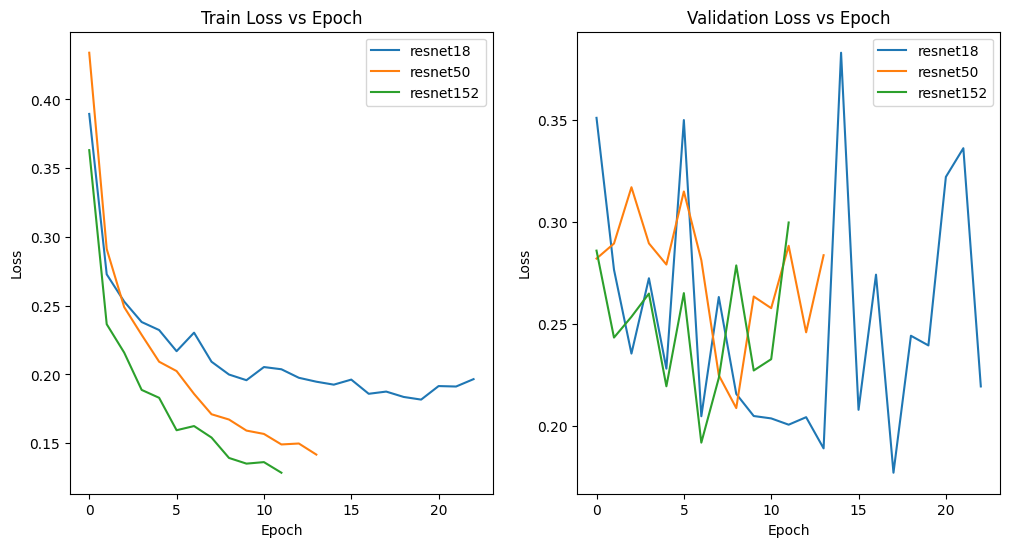

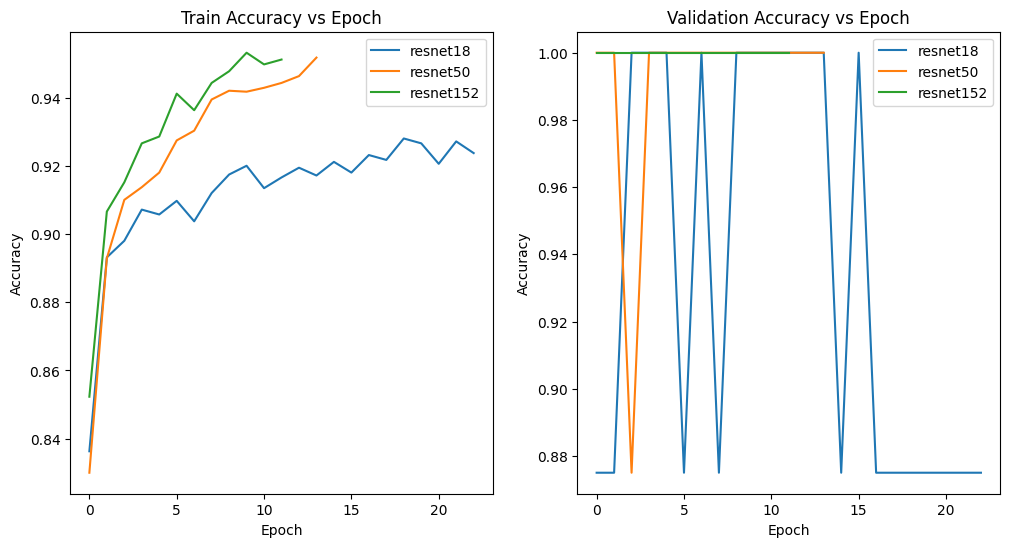

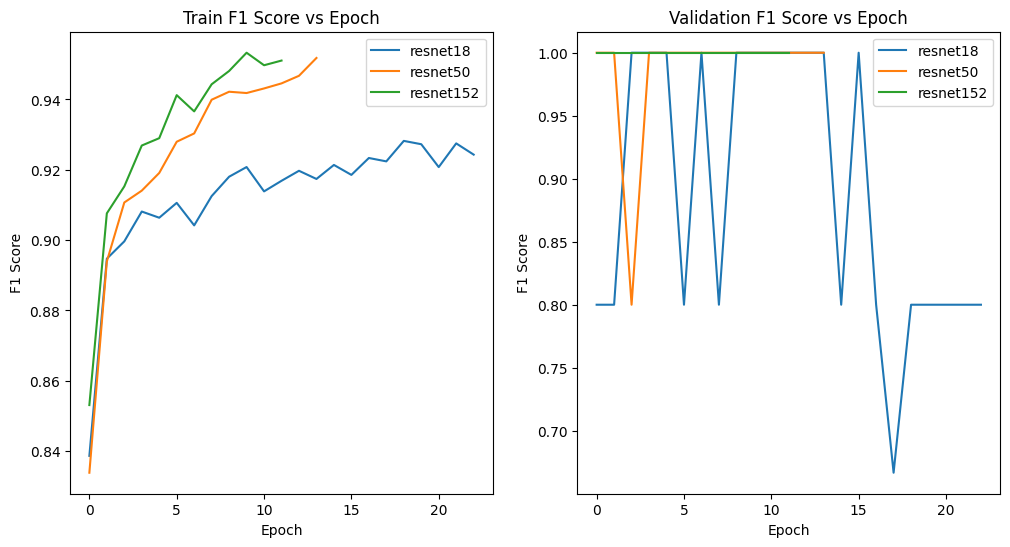

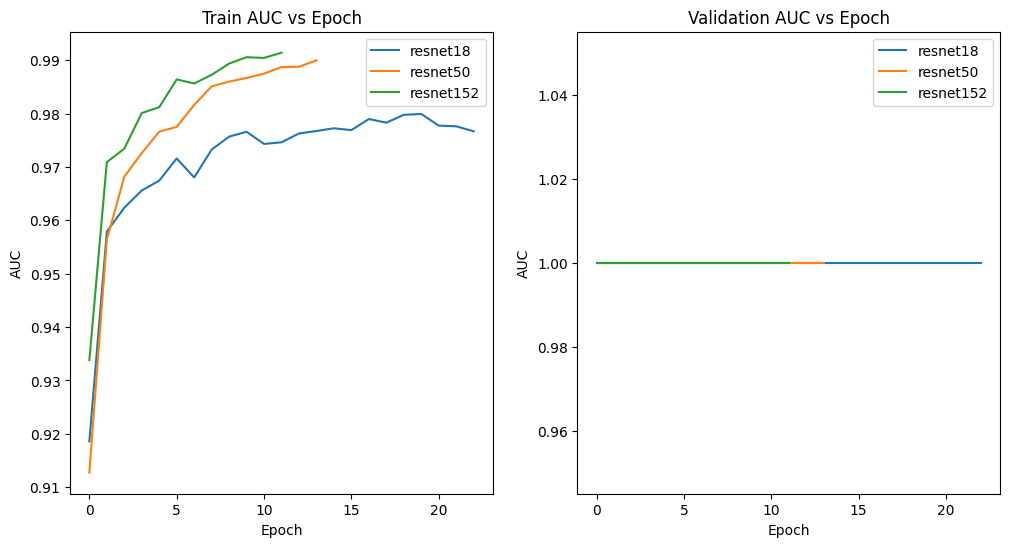

In [ ]:
learning_comparasion_plot(trained_results)

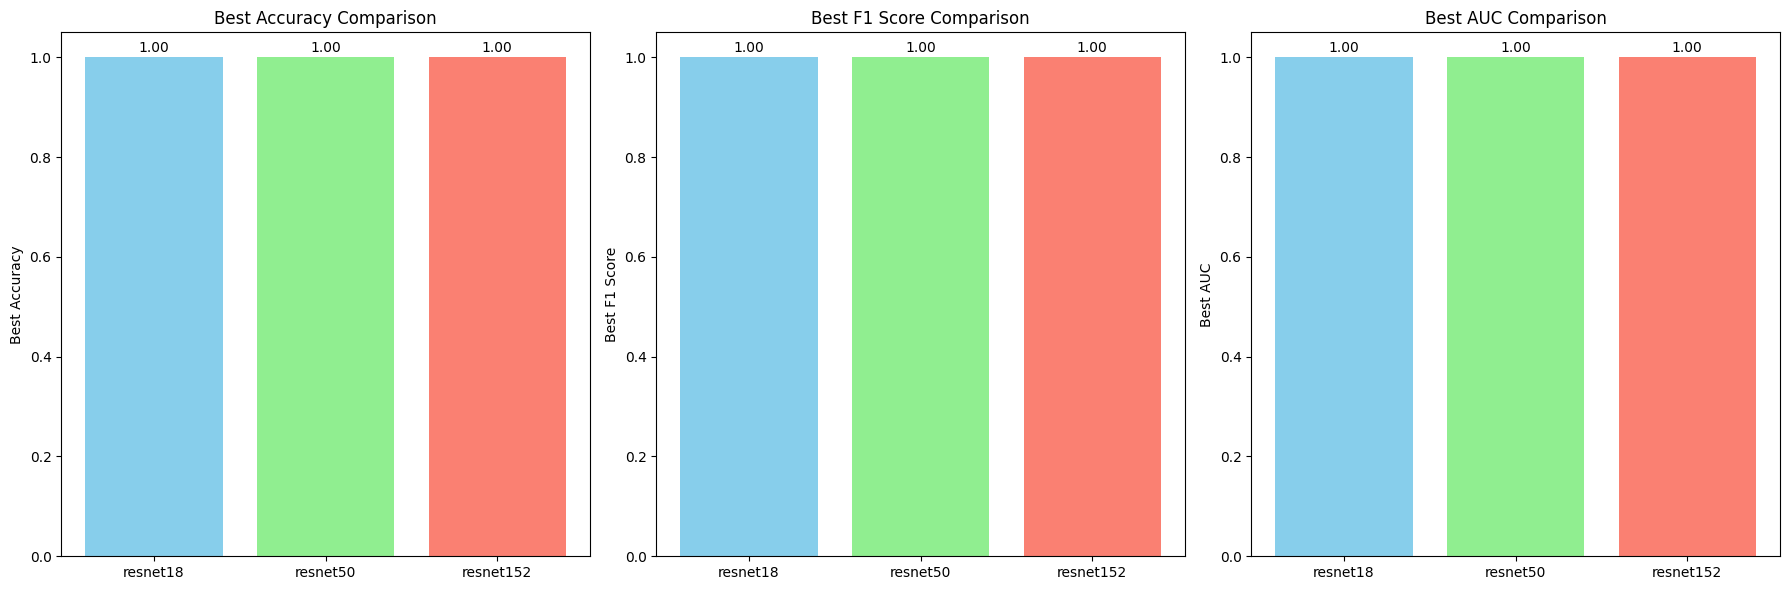

In [ ]:
plot_best_matrics(trained_results)

/tmp/ipykernel_1475/2095122624.py:7: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



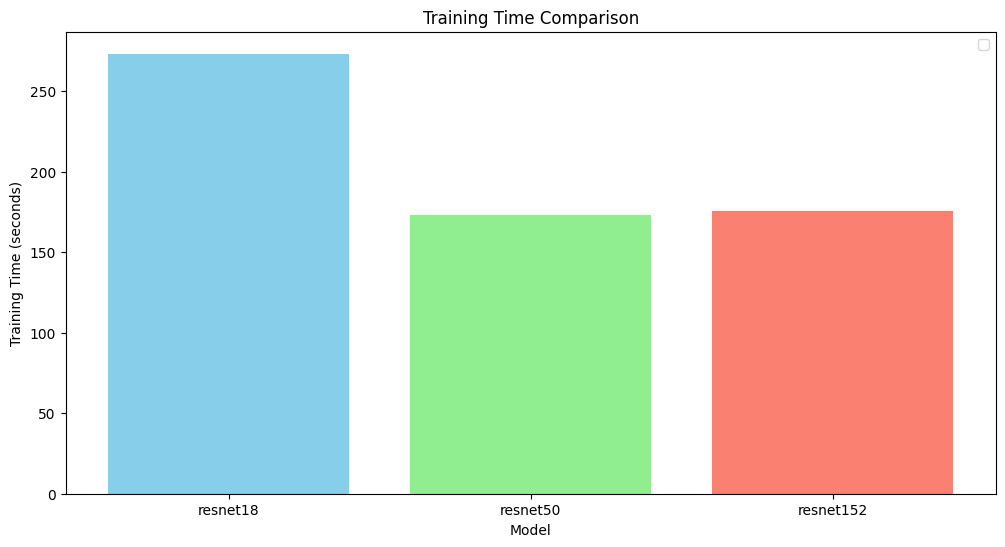

In [ ]:
plot_training_time(training_times)

In [ ]:
final_models = {}

for model_name in trained_results.keys():

  model_factory = models[model_name][0]

  weight = models[model_name][1]

  model_instance = model_factory().to(device)

  model_instance.load_state_dict(
      torch.load(f"{model_name}.pth", map_location=device)
  )


  final_models[model_name] = {
      'instance' : model_instance,
      'weight' : weight
  }

In [ ]:
test_result = {}
for model_name, model_info in final_models.items():
  model_instance = model_info['instance']
  weight = model_info['weight']

  test_result[model_name] = test_step(model_instance , test_loader,criterion, accuracy, f1_score, binary_auc)


In [ ]:
import seaborn as sns

def plot_confusion_matrix(test_results):
    plt.figure(figsize=(15, 5))  #

    for i, model_name in enumerate(test_results.keys()):
        plt.subplot(1, 3, i + 1)
        sns.heatmap(test_results[model_name][4], annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix\n{model_name}")
        plt.xlabel("Predicted Labels")
        plt.ylabel("True Labels")

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_test_matrics(results):
  metrics = [0, 2, 3]
  metric_display_names = [ 'Accuracy', 'F1 Score', 'AUC']

  plt.figure(figsize=(18,6))
  model_names = list(results.keys())

  for i, metric in enumerate(metrics):
    best_metric_values = []
    for model_name in model_names:
      best_metric_values.append(results[model_name][metric])

    plt.subplot(1,3,i+1)
    plt.bar(model_names, best_metric_values, color =['skyblue', 'lightgreen', 'salmon'])

    plt.ylabel(f"Test {metric_display_names[i]}")
    plt.title(f"Test {metric_display_names[i]} Comparison")

    for j, v in enumerate(best_metric_values):
      plt.text(j, v + 0.01, f"{v:.2f}", ha='center')

  plt.tight_layout()
  plt.show()


In [ ]:
test_result

{'resnet18': (0.9139999747276306,
  0.2325711385346949,
  0.800000011920929,
  0.9637616276741028,
  array([[371,  35],
         [  8,  86]])),
 'resnet50': (0.9179999828338623,
  0.21979107707738876,
  0.7980295419692993,
  0.9621894955635071,
  array([[378,  28],
         [ 13,  81]])),
 'resnet152': (0.921999990940094,
  0.17422315338626504,
  0.800000011920929,
  0.9693689942359924,
  array([[383,  23],
         [ 16,  78]]))}

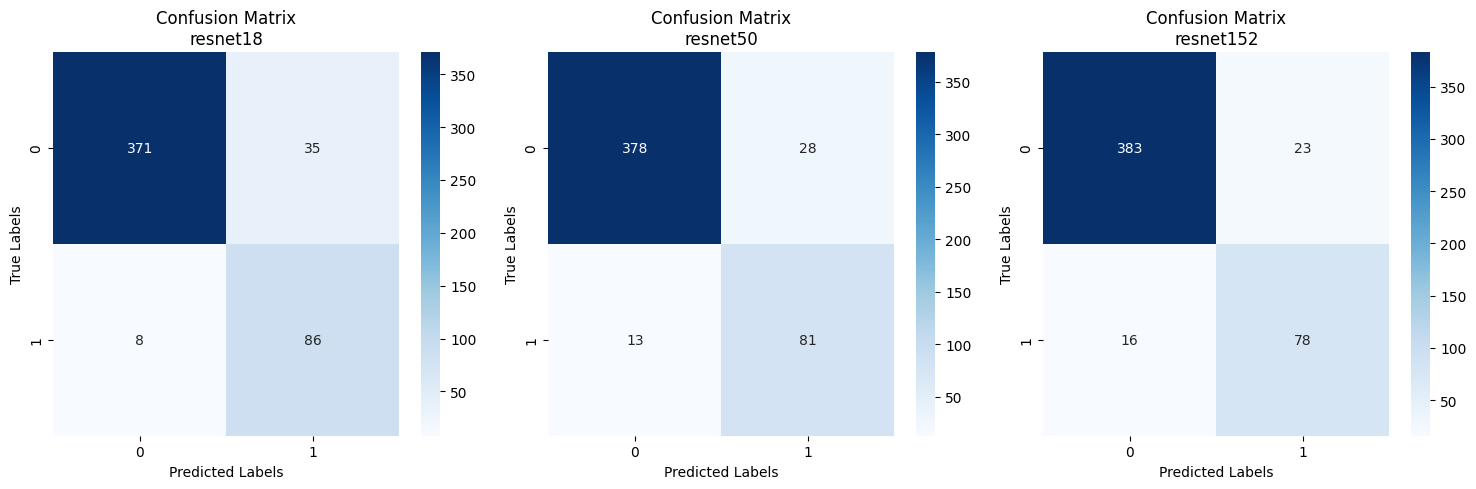

In [ ]:
plot_confusion_matrix(test_result)

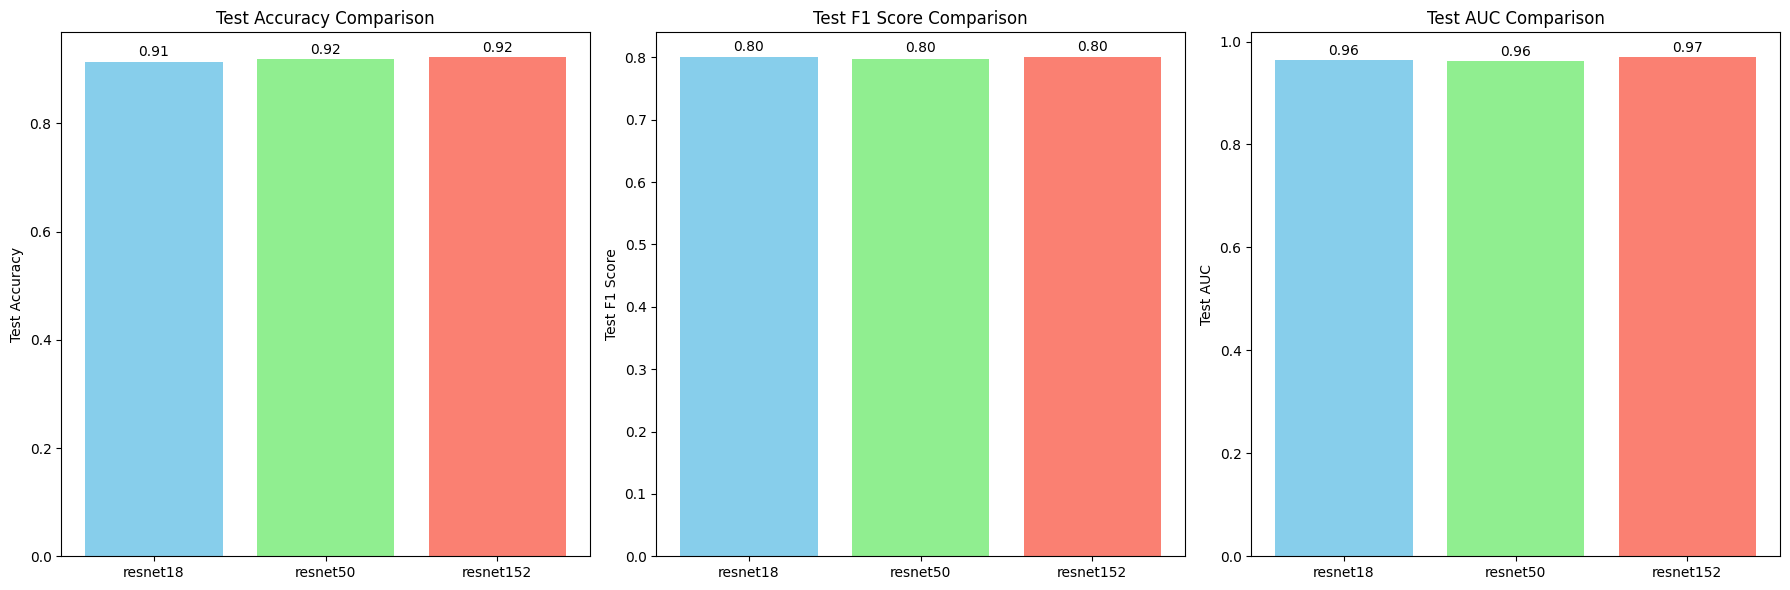

In [ ]:
plot_test_matrics(test_result)

In [ ]:
import random
import matplotlib.pyplot as plt
import torch
np.random.seed(42)
torch.cuda.manual_seed(42)
def plot_predictions(final_models, test_loader, num_samples=5):

  dataset = test_loader.dataset
  random_indices = random.sample(range(len(dataset)), num_samples)

  num_models = len(final_models)

  fig, axes = plt.subplots(num_models, num_samples, figsize=(num_samples*2, num_models*2))

  for row, (model_name, model_info) in enumerate(final_models.items()):

    model = model_info['instance']
    weight = model_info['weight']

    model.eval()
    dataset.transform = weight.transforms()

    for col, idx in enumerate(random_indices):

      image_tensor, label_true = dataset[idx]
      image_tensor = image_tensor.unsqueeze(0).to(device)

      with torch.inference_mode():
        output = model(image_tensor).squeeze(1)
        prob = torch.sigmoid(output).item()

      label_pred = 1 if prob >= 0.5 else 0

      image = image_tensor.squeeze().permute(1,2,0).cpu().numpy()

      ax = axes[row, col] if num_models > 1 else axes[col]

      ax.imshow(image)
      ax.axis("off")

      pred_text = "Male" if label_pred == 1 else "Female"
      true_text = "Male" if label_true == 1 else "Female"

      ax.set_title(
        f"P:{pred_text}\nT:{true_text}\n{prob:.2f}\n{model_name}",
        fontsize=8,
        color="green" if label_pred == label_true else "red"
      )

      if col == 0:
        ax.set_ylabel(model_name, fontsize=12)

  plt.tight_layout()
  plt.show()

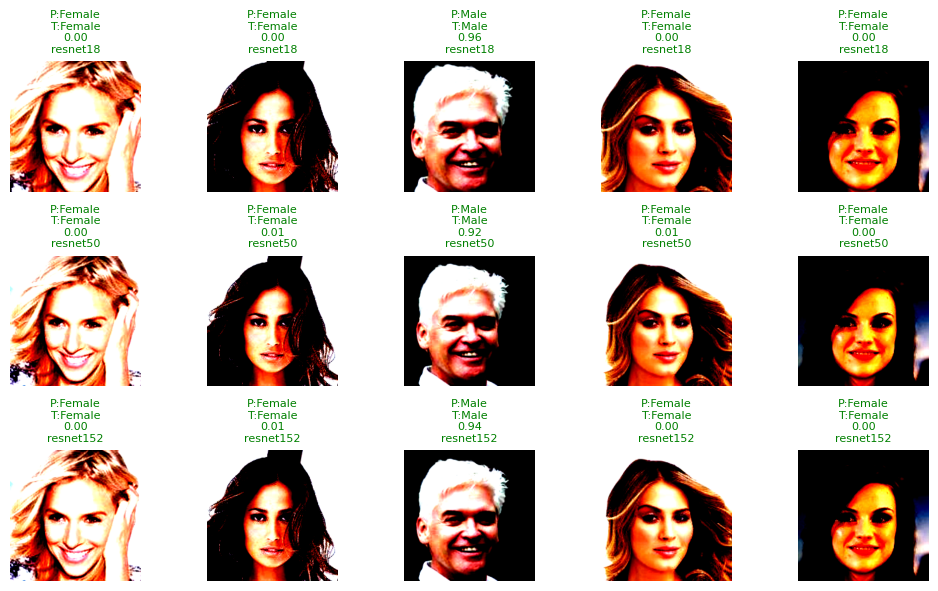

In [ ]:
plot_predictions(final_models , test_loader)

In [ ]:
!gdown "https://drive.google.com/uc?id=1oqjqMbPdHUp9LsehY3yoVbl-7H-38Uy5" -O sample.jpg


Downloading...
From: https://drive.google.com/uc?id=1oqjqMbPdHUp9LsehY3yoVbl-7H-38Uy5
To: /content/sample.jpg
100% 18.8k/18.8k [00:00<00:00, 50.9MB/s]


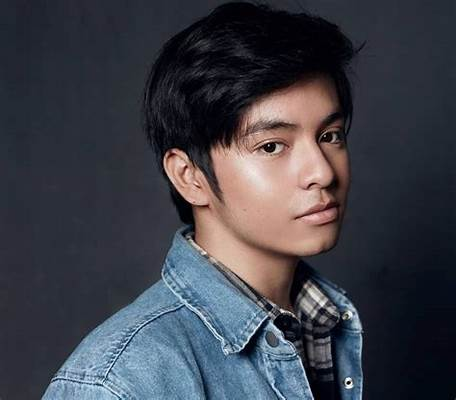

In [ ]:
image = Image.open("sample.jpg")
image

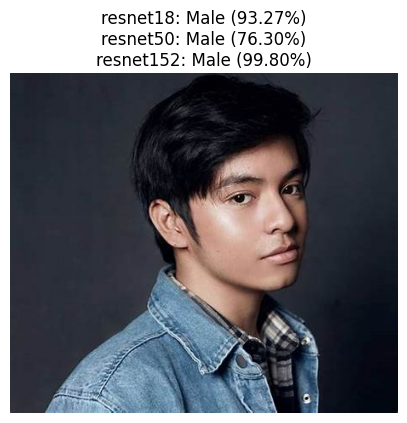

In [ ]:
predictions = []

for model_name, model_info in final_models.items():

  model_instance = model_info['instance']
  weight = model_info['weight']

  model_instance.eval()
  transform = weight.transforms()

  image_tensor = transform(image).unsqueeze(0).to(device)

  with torch.inference_mode():
    output = model_instance(image_tensor).squeeze(1)
    prob = torch.sigmoid(output).item()

  label = 1 if prob >= 0.5 else 0
  label_text = "Male" if label == 1 else "Female"

  predictions.append(f"{model_name}: {label_text} ({prob:.2%})")


plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

plt.title("\n".join(predictions), fontsize=12)

plt.show()